The dataset was annotated in Roboflow and it has been uploaded on the following public Google Drive.


In [1]:
# https://drive.google.com/file/d/16zWWdRnIYnay6Hm4cw_FEv1KBu_VDqT9/view?usp=sharing



In [2]:
import os
!pip install gdown

# Google Drive file ID for the provided link
file_id = '16zWWdRnIYnay6Hm4cw_FEv1KBu_VDqT9'
output_filename = 'dataset.zip'

# Download the file using gdown
!gdown --id {file_id} -O {output_filename}

print(f"Downloaded {output_filename} successfully.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=16zWWdRnIYnay6Hm4cw_FEv1KBu_VDqT9
From (redirected): https://drive.google.com/uc?id=16zWWdRnIYnay6Hm4cw_FEv1KBu_VDqT9&confirm=t&uuid=37adc47f-9fba-419b-b108-840a4106bf9b
To: /content/dataset.zip
100% 85.6M/85.6M [00:01<00:00, 45.5MB/s]
Downloaded dataset.zip successfully.


In [3]:
import zipfile

# Create a directory to extract files into
extract_dir = 'dataset_files'
os.makedirs(extract_dir, exist_ok=True)

# Unzip the downloaded file
with zipfile.ZipFile(output_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted contents of {output_filename} to {extract_dir}/")
print(f"Files in '{extract_dir}':\n{os.listdir(extract_dir)}")

Extracted contents of dataset.zip to dataset_files/
Files in 'dataset_files':
['train', 'README.roboflow.txt']


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [5]:
!pip install pycocotools

In [6]:
from pycocotools.coco import COCO

class SegmentationDataset(Dataset):
    def __init__(self, root_dir, annotation_file, transform=None):
        self.root_dir = root_dir
        self.coco = COCO(annotation_file)
        self.ids = list(self.coco.imgs.keys())
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        img_id = self.ids[index]
        img_info = self.coco.loadImgs(img_id)[0]
        image_path = os.path.join(self.root_dir, img_info['file_name'])
        image = Image.open(image_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        # Initialize a blank mask as a NumPy array (binary, 0 or 1)
        height = img_info['height']
        width = img_info['width']
        combined_mask_np = np.zeros((height, width), dtype=np.uint8)

        for ann in anns:
            # Get the binary mask for the current annotation
            # annToMask returns a 2D numpy array where pixels inside the segmentation are 1, outside are 0
            current_ann_mask_np = self.coco.annToMask(ann)
            # Combine masks using logical OR (max operation for binary masks)
            combined_mask_np = np.maximum(combined_mask_np, current_ann_mask_np)

        # Convert the combined NumPy mask to a PIL Image in 'L' (grayscale) mode, scaled to 0-255
        mask = Image.fromarray(combined_mask_np * 255, mode='L')

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

In [7]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Adjust paths for COCO dataset structure
dataset_root = os.path.join(extract_dir, 'train') # Assuming images are directly under 'train'
annotation_path = os.path.join(dataset_root, '_annotations.coco.json') # Use the path to the coco annotation file

train_dataset = SegmentationDataset(dataset_root, annotation_path, transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

In [9]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        # Encoder
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        d1 = self.down1(x)
        d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2))
        d4 = self.down4(self.pool(d3))

        # Bottleneck
        bn = self.bottleneck(self.pool(d4))

        # Decoder
        up4 = self.up4(bn)
        up4 = torch.cat([up4, d4], dim=1)
        up4 = self.conv4(up4)

        up3 = self.up3(up4)
        up3 = torch.cat([up3, d3], dim=1)
        up3 = self.conv3(up3)

        up2 = self.up2(up3)
        up2 = torch.cat([up2, d2], dim=1)
        up2 = self.conv2(up2)

        up1 = self.up1(up2)
        up1 = torch.cat([up1, d1], dim=1)
        up1 = self.conv1(up1)

        return self.final(up1)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [11]:
num_epochs = 20
train_losses = [] # List to store loss per epoch

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader)) # Store average epoch loss
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses[-1]:.4f}")

/tmp/ipykernel_9728/1152628411.py:35: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(combined_mask_np * 255, mode='L')


Epoch [1/20], Loss: 0.6614
Epoch [2/20], Loss: 0.6455
Epoch [3/20], Loss: 0.6264
Epoch [4/20], Loss: 0.6016
Epoch [5/20], Loss: 0.5794
Epoch [6/20], Loss: 0.5472
Epoch [7/20], Loss: 0.5254
Epoch [8/20], Loss: 0.5968
Epoch [9/20], Loss: 0.5514
Epoch [10/20], Loss: 0.5312
Epoch [11/20], Loss: 0.5377
Epoch [12/20], Loss: 0.5270
Epoch [13/20], Loss: 0.5187
Epoch [14/20], Loss: 0.5446
Epoch [15/20], Loss: 0.5470
Epoch [16/20], Loss: 0.5462
Epoch [17/20], Loss: 0.5217
Epoch [18/20], Loss: 0.5210
Epoch [19/20], Loss: 0.5882
Epoch [20/20], Loss: 0.5473


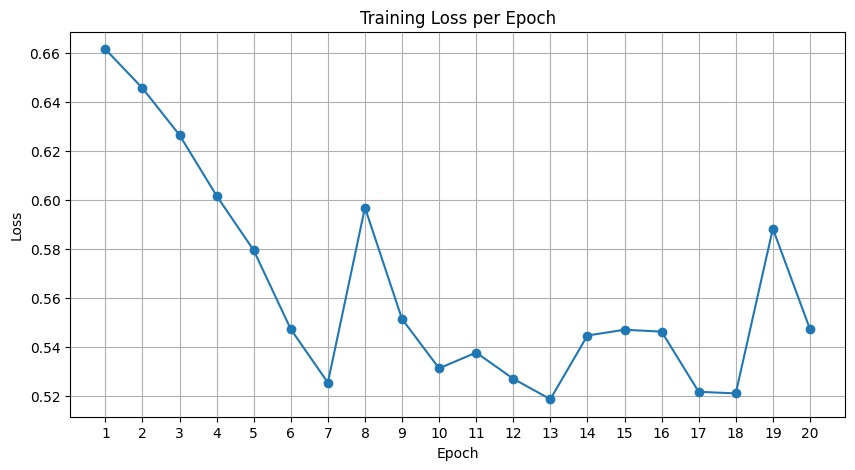

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(range(1, num_epochs + 1))
plt.show()

/tmp/ipykernel_9728/1152628411.py:35: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(combined_mask_np * 255, mode='L')


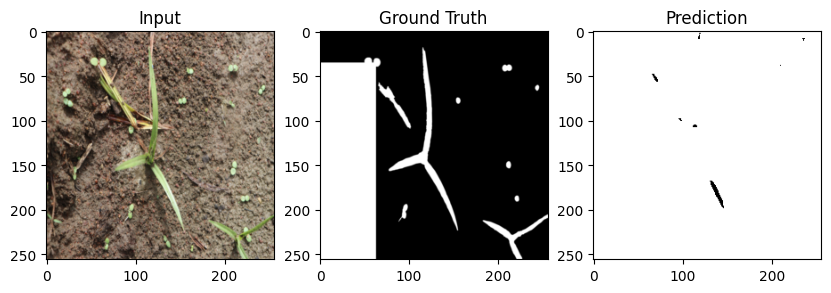

In [13]:
model.eval()

with torch.no_grad():
    # Select a specific image from the dataset (e.g., the first one)
    image, mask = train_dataset[0]

    # Add batch dimension to the image and mask
    images = image.unsqueeze(0).to(device)
    masks = mask.unsqueeze(0).to(device)

    outputs = torch.sigmoid(model(images))

    preds = (outputs > 0.2).float()

    # Show the selected image
    plt.figure(figsize=(10, 3))

    plt.subplot(1, 3, 1)
    plt.title("Input")
    plt.imshow(images[0].cpu().permute(1, 2, 0))

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(masks[0].cpu().squeeze(), cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(preds[0].cpu().squeeze(), cmap='gray')

    plt.show()

In [14]:
image2=images
masks2=masks

# Reducing the learning rate
1e-4 -> 1e-5

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

In [16]:
num_epochs = 20
train_losses = [] # List to store loss per epoch

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader)) # Store average epoch loss
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses[-1]:.4f}")

/tmp/ipykernel_9728/1152628411.py:35: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(combined_mask_np * 255, mode='L')


Epoch [1/20], Loss: 0.7253
Epoch [2/20], Loss: 0.7253
Epoch [3/20], Loss: 0.7230
Epoch [4/20], Loss: 0.7223
Epoch [5/20], Loss: 0.7158
Epoch [6/20], Loss: 0.7157
Epoch [7/20], Loss: 0.7157
Epoch [8/20], Loss: 0.7146
Epoch [9/20], Loss: 0.7111
Epoch [10/20], Loss: 0.7103
Epoch [11/20], Loss: 0.7077
Epoch [12/20], Loss: 0.7048
Epoch [13/20], Loss: 0.7022
Epoch [14/20], Loss: 0.6992
Epoch [15/20], Loss: 0.6950
Epoch [16/20], Loss: 0.6904
Epoch [17/20], Loss: 0.6815
Epoch [18/20], Loss: 0.6573
Epoch [19/20], Loss: 0.6015
Epoch [20/20], Loss: 0.5736


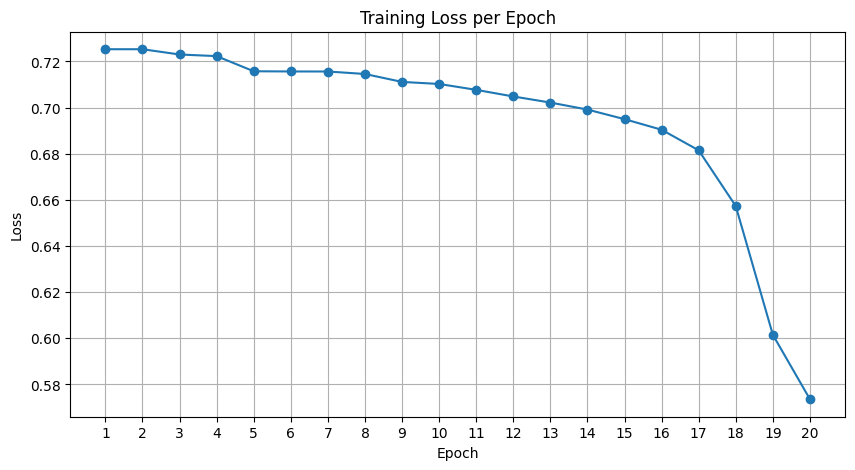

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(range(1, num_epochs + 1))
plt.show()

/tmp/ipykernel_9728/1152628411.py:35: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(combined_mask_np * 255, mode='L')


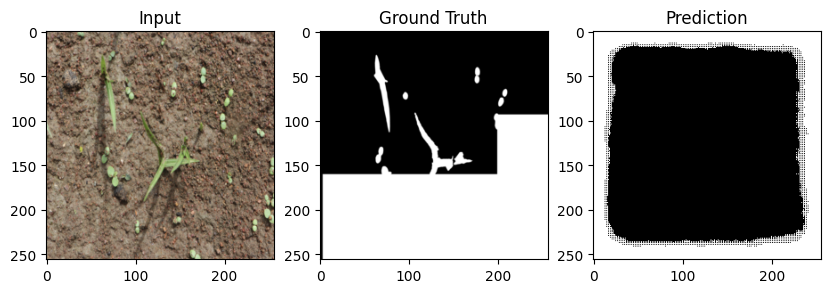

In [18]:
model.eval()

with torch.no_grad():
    for images, masks in train_loader:
        images = images.to(device)
        outputs = torch.sigmoid(model(images))

        preds = (outputs > 0.2).float()

        # Show first image
        plt.figure(figsize=(10, 3))

        plt.subplot(1, 3, 1)
        plt.title("Input")
        plt.imshow(images[0].cpu().permute(1, 2, 0))

        plt.subplot(1, 3, 2)
        plt.title("Ground Truth")
        plt.imshow(masks[0].cpu().squeeze(), cmap='gray')

        plt.subplot(1, 3, 3)
        plt.title("Prediction")
        plt.imshow(preds[0].cpu().squeeze(), cmap='gray')

        plt.show()
        break

# Increasing the Learning Rate
1e-4 to 1e-2

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

In [20]:
num_epochs = 20
train_losses = [] # List to store loss per epoch

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader)) # Store average epoch loss
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses[-1]:.4f}")

/tmp/ipykernel_9728/1152628411.py:35: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(combined_mask_np * 255, mode='L')


Epoch [1/20], Loss: 124780207.1941
Epoch [2/20], Loss: 255533.4168
Epoch [3/20], Loss: 0.6214
Epoch [4/20], Loss: 0.5854
Epoch [5/20], Loss: 0.5509
Epoch [6/20], Loss: 0.5916
Epoch [7/20], Loss: 0.5491
Epoch [8/20], Loss: 0.5258
Epoch [9/20], Loss: 0.6235
Epoch [10/20], Loss: 0.5662
Epoch [11/20], Loss: 0.5711
Epoch [12/20], Loss: 0.5385
Epoch [13/20], Loss: 0.5352
Epoch [14/20], Loss: 0.5300
Epoch [15/20], Loss: 0.5452
Epoch [16/20], Loss: 0.5511
Epoch [17/20], Loss: 0.5218
Epoch [18/20], Loss: 0.5622
Epoch [19/20], Loss: 0.5505
Epoch [20/20], Loss: 0.5554


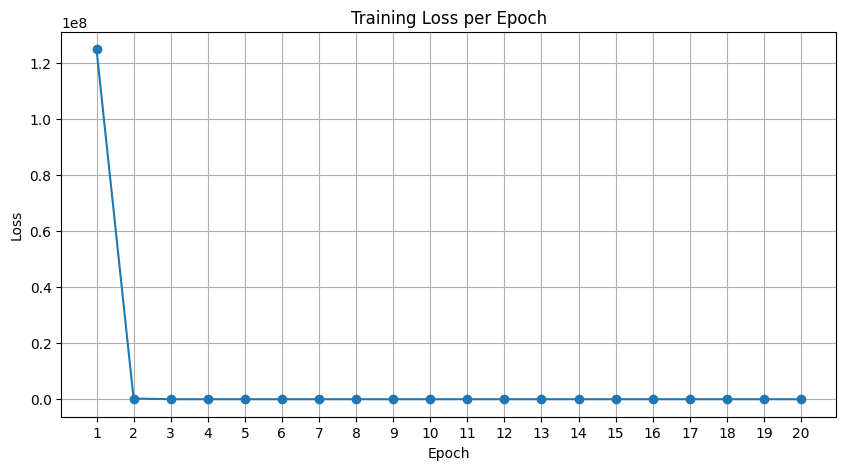

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(range(1, num_epochs + 1))
plt.show()

/tmp/ipykernel_9728/1152628411.py:35: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(combined_mask_np * 255, mode='L')


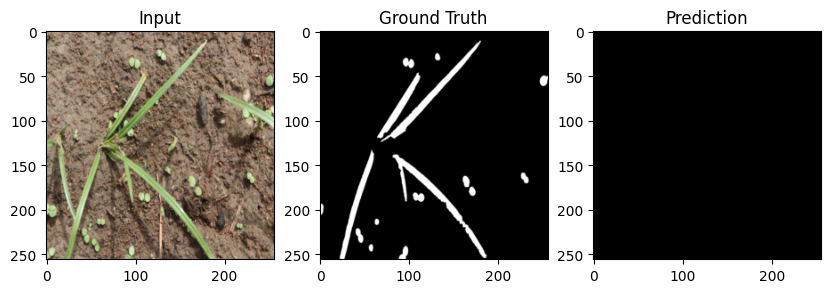

In [22]:
model.eval()

with torch.no_grad():
    for images, masks in train_loader:
        images = images.to(device)
        outputs = torch.sigmoid(model(images))

        preds = (outputs > 0.2).float()

        # Show first image
        plt.figure(figsize=(10, 3))

        plt.subplot(1, 3, 1)
        plt.title("Input")
        plt.imshow(images[0].cpu().permute(1, 2, 0))

        plt.subplot(1, 3, 2)
        plt.title("Ground Truth")
        plt.imshow(masks[0].cpu().squeeze(), cmap='gray')

        plt.subplot(1, 3, 3)
        plt.title("Prediction")
        plt.imshow(preds[0].cpu().squeeze(), cmap='gray')

        plt.show()
        break

# Discussion of Results
With a learning rate of 1e-4 and 1e-5 at least the losses are reduced during training, and the predicted mask has some shape to it. 1e-4 was the best as it could follow the shape of the grass and weeds. 1e-5 might be too small and would require more epochs to converge.

1e-2 is too large and does not train the model properly hence why the predicted mask is empty.